     ROC CURVE — HEART DISEASE PREDICTION

📌 BASIC EDA
--------------------------------------------------
Shape : (303, 15)

Columns:
['Unnamed: 0', 'Age', 'Sex', 'ChestPain', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca', 'Thal', 'AHD']

First 5 Rows:
   Unnamed: 0  Age  Sex     ChestPain  RestBP  Chol  Fbs  RestECG  MaxHR  \
0           1   63    1       typical     145   233    1        2    150   
1           2   67    1  asymptomatic     160   286    0        2    108   
2           3   67    1  asymptomatic     120   229    0        2    129   
3           4   37    1    nonanginal     130   250    0        0    187   
4           5   41    0    nontypical     130   204    0        2    172   

   ExAng  Oldpeak  Slope   Ca        Thal  AHD  
0      0      2.3      3  0.0       fixed   No  
1      1      1.5      2  3.0      normal  Yes  
2      1      2.6      2  2.0  reversable  Yes  
3      0      3.5      3  0.0      normal   No  
4      0    

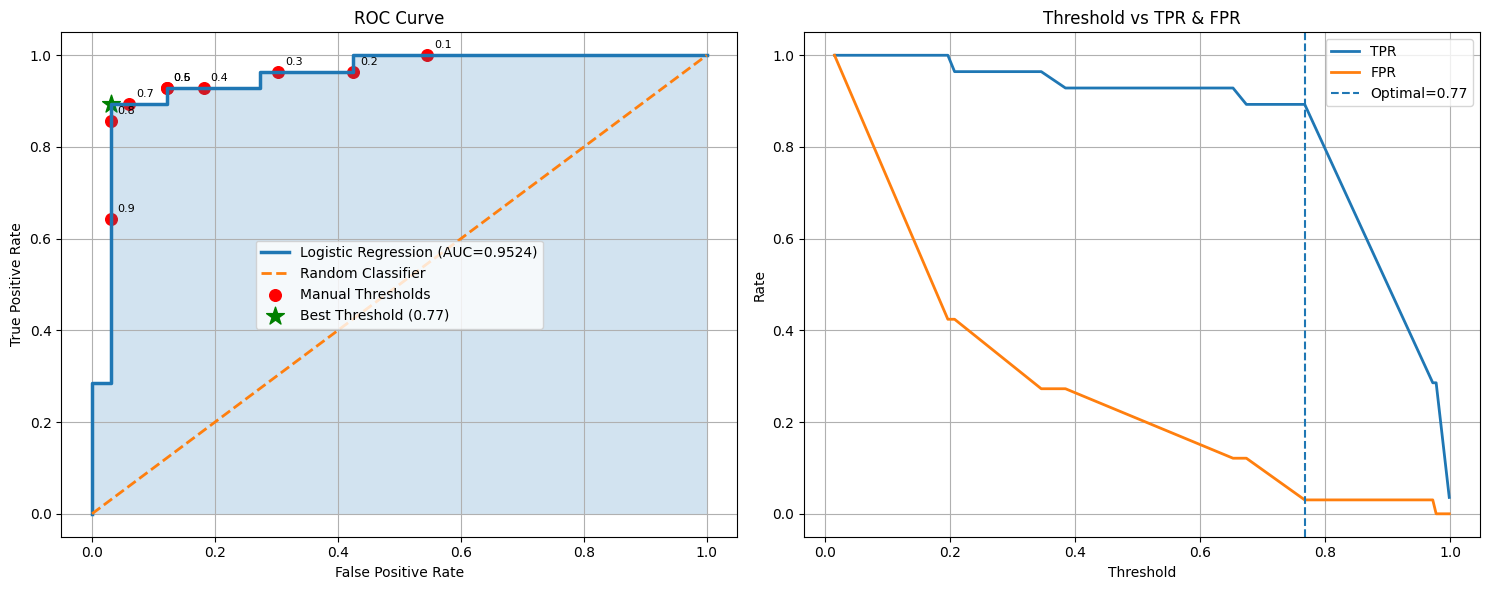


📌 STEP 7 — AUC SCORE
--------------------------------------------------
ROC AUC : 0.9524
Excellent Model

Reference
1.00 = Perfect
0.90 = Excellent
0.80 = Good
0.70 = Fair
0.50 = Random Guess

📌 STEP 8 — MODEL EVALUATION
--------------------------------------------------

DEFAULT THRESHOLD (0.50)

Accuracy : 0.9016
Precision: 0.8667
Recall   : 0.9286
F1 Score : 0.8966
ROC AUC  : 0.9524

BEST THRESHOLD

Accuracy : 0.9344
Precision: 0.9615
Recall   : 0.8929
F1 Score : 0.9259

📌 CONFUSION MATRIX
--------------------------------------------------
[[32  1]
 [ 3 25]]

TN = 32
FP = 1
FN = 3
TP = 25

📌 CLASSIFICATION REPORT
--------------------------------------------------
               precision    recall  f1-score   support

   No Disease       0.91      0.97      0.94        33
Heart Disease       0.96      0.89      0.93        28

     accuracy                           0.93        61
    macro avg       0.94      0.93      0.93        61
 weighted avg       0.94      0.93      0.93   

In [ ]:
 # ==========================================================
# ROC CURVE — HEART DISEASE PREDICTION
# Dataset:
# https://raw.githubusercontent.com/rashida048/Datasets/master/Heart.csv
# ==========================================================

# ==========================
# 1. IMPORT LIBRARIES
# ==========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.preprocessing import (
    StandardScaler
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score
)

print("=" * 60)
print("     ROC CURVE — HEART DISEASE PREDICTION")
print("=" * 60)

# ==========================
# 2. LOAD DATASET
# ==========================

url = "https://raw.githubusercontent.com/rashida048/Datasets/master/Heart.csv"

df = pd.read_csv(url)

print("\n📌 BASIC EDA")
print("-" * 50)

print("Shape :", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())

# ==========================
# 3. TARGET CONVERSION
# ==========================

# AHD
# No  -> 0
# Yes -> 1

df["AHD"] = df["AHD"].map({
    "No": 0,
    "Yes": 1
})

print("\nTarget Distribution:")
print(df["AHD"].value_counts())

# ==========================
# 4. MISSING VALUES
# ==========================

print("\n📌 MISSING VALUES")
print("-" * 50)

print(df.isnull().sum())

# Fill Ca missing values

if df["Ca"].isnull().sum() > 0:
    df["Ca"] = df["Ca"].fillna(df["Ca"].median())

print("\nMissing Values After Handling:")
print(df.isnull().sum())

# ==========================
# 5. DUPLICATES
# ==========================

print("\n📌 DUPLICATES")
print("-" * 50)

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

if duplicates > 0:
    df.drop_duplicates(inplace=True)

# ==========================
# 6. REMOVE USELESS COLUMN
# ==========================

if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

# ==========================
# 7. OUTLIER CHECK
# ==========================

print("\n📌 BASIC OUTLIER CLEANING")
print("-" * 50)

before = len(df)

df = df[df["RestBP"] > 0]
df = df[df["Chol"] > 0]

after = len(df)

print("Rows Removed :", before - after)
print("New Shape :", df.shape)

# ==========================
# 8. FEATURE ENGINEERING
# ==========================

print("\n📌 FEATURE ENGINEERING")
print("-" * 50)

# Age Group

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0,45,60,100],
    labels=[0,1,2]
).astype(int)

# Heart Rate Ratio

df["HR_Ratio"] = (
    df["MaxHR"] /
    (220 - df["Age"])
)

# Heart Rate Reserve

df["HR_Reserve"] = (
    (220 - df["Age"])
    - df["MaxHR"]
)

# Cholesterol Age Interaction

df["Chol_Age"] = (
    df["Chol"] *
    df["Age"]
) / 1000

# High BP

df["High_BP"] = (
    df["RestBP"] >= 130
).astype(int)

print("Created Features:")
print("""
Age_Group
HR_Ratio
HR_Reserve
Chol_Age
High_BP
""")

# ==========================
# 9. ENCODING
# ==========================

print("\n📌 ENCODING")
print("-" * 50)

categorical_cols = [
    "ChestPain",
    "Thal"
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("Encoding Complete")

# ==========================
# 10. FEATURES & TARGET
# ==========================

print("\n📌 FEATURE SELECTION")
print("-" * 50)

X = df.drop("AHD", axis=1)
y = df["AHD"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

print("\nClass Balance:")
print(y.value_counts())

# ==========================
# 11. TRAIN TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)

# ==========================
# 12. FEATURE SCALING
# ==========================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\n✅ StandardScaler Applied")

# ==========================================================
#        ROC CURVE FLOW STARTS HERE
# ==========================================================

print("\n" + "="*60)
print("        ROC CURVE FLOW STARTS HERE")
print("="*60)

# ==========================================================
# 13. TRAIN LOGISTIC REGRESSION
# ==========================================================

print("\n📌 STEP 1 — TRAIN LOGISTIC REGRESSION")
print("-"*50)

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train, y_train)

print("✅ Model Trained Successfully")

# ==========================================================
# CROSS VALIDATION
# ==========================================================

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("\nCross Validation ROC-AUC")

print("Scores :", cv_scores)
print("Average :", cv_scores.mean())
print("Std Dev :", cv_scores.std())

# ==========================================================
# 14. PREDICT PROBABILITIES
# ==========================================================

print("\n📌 STEP 2 — PREDICT PROBABILITIES")
print("-"*50)

y_probability = model.predict_proba(X_test)

# Probability of Disease

y_proba = y_probability[:,1]

print(f"{'Sample':<8}{'No Disease':<15}{'Disease':<15}{'Actual'}")
print("-"*55)

for i in range(min(10,len(y_test))):

    print(
        f"{i+1:<8}"
        f"{y_probability[i][0]:<15.4f}"
        f"{y_probability[i][1]:<15.4f}"
        f"{y_test.iloc[i]}"
    )

# ==========================================================
# 15. MANUAL THRESHOLD ANALYSIS
# ==========================================================

print("\n📌 STEP 3 — THRESHOLD ANALYSIS")
print("-"*50)

print(
"""
Lower Threshold
↓

More Positive Predictions

↓

Higher Recall

↓

Higher False Positives
"""
)

thresholds_manual = [

0.90,
0.80,
0.70,
0.60,
0.50,
0.40,
0.30,
0.20,
0.10

]

print(
f"{'Threshold':<12}"
f"{'TP':<6}"
f"{'FP':<6}"
f"{'TN':<6}"
f"{'FN':<6}"
f"{'TPR':<10}"
f"{'FPR'}"
)

print("-"*70)

manual_tpr=[]

manual_fpr=[]

for threshold in thresholds_manual:

    y_pred_threshold = (
        y_proba >= threshold
    ).astype(int)

    tn,fp,fn,tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    tpr = tp/(tp+fn)

    fpr = fp/(fp+tn)

    manual_tpr.append(tpr)

    manual_fpr.append(fpr)

    print(

        f"{threshold:<12.1f}"
        f"{tp:<6}"
        f"{fp:<6}"
        f"{tn:<6}"
        f"{fn:<6}"
        f"{tpr:<10.4f}"
        f"{fpr:.4f}"

    )

print("\nMeaning")

print("TPR = TP / (TP + FN)")
print("FPR = FP / (FP + TN)")

# ==========================================================
# 16. ROC CURVE
# ==========================================================

print("\n📌 STEP 4 — COMPUTE ROC CURVE")
print("-"*50)

fpr_curve, tpr_curve, thresholds_curve = roc_curve(
    y_test,
    y_proba
)

auc_score = roc_auc_score(
    y_test,
    y_proba
)

print("Total Thresholds :",len(thresholds_curve))

print("ROC AUC :",round(auc_score,4))

# ==========================================================
# 17. OPTIMAL THRESHOLD
# ==========================================================

print("\n📌 STEP 5 — BEST THRESHOLD")
print("-"*50)

# Youden Index

youden = tpr_curve - fpr_curve

best_index = np.argmax(youden)

optimal_threshold = thresholds_curve[
    best_index
]

optimal_tpr = tpr_curve[
    best_index
]

optimal_fpr = fpr_curve[
    best_index
]

print("Optimal Threshold :",round(optimal_threshold,4))

print("TPR :",round(optimal_tpr,4))

print("FPR :",round(optimal_fpr,4))

print(
"""
This threshold gives

Highest Recall

Lowest False Positive Rate

Balanced Performance
"""
)


# ==========================================================
# 18. ROC CURVE PLOT
# ==========================================================

print("\n📌 STEP 6 — ROC CURVE PLOT")
print("-"*50)

fig, axes = plt.subplots(1,2,figsize=(15,6))

# ----------------------------------------------------------
# ROC CURVE
# ----------------------------------------------------------

ax = axes[0]

ax.plot(
    fpr_curve,
    tpr_curve,
    linewidth=2.5,
    label=f"Logistic Regression (AUC={auc_score:.4f})"
)

ax.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

# Manual Threshold Points

ax.scatter(
    manual_fpr,
    manual_tpr,
    s=70,
    color="red",
    label="Manual Thresholds"
)

for t,x,y in zip(
    thresholds_manual,
    manual_fpr,
    manual_tpr
):

    ax.annotate(
        str(t),
        (x,y),
        textcoords="offset points",
        xytext=(5,5),
        fontsize=8
    )

# Best Threshold

ax.scatter(
    optimal_fpr,
    optimal_tpr,
    s=180,
    marker="*",
    color="green",
    label=f"Best Threshold ({optimal_threshold:.2f})"
)

ax.fill_between(
    fpr_curve,
    tpr_curve,
    alpha=0.2
)

ax.set_xlabel("False Positive Rate")

ax.set_ylabel("True Positive Rate")

ax.set_title("ROC Curve")

ax.legend()

ax.grid(True)

# ----------------------------------------------------------
# Threshold Graph
# ----------------------------------------------------------

ax2 = axes[1]

ax2.plot(
    thresholds_curve,
    tpr_curve,
    linewidth=2,
    label="TPR"
)

ax2.plot(
    thresholds_curve,
    fpr_curve,
    linewidth=2,
    label="FPR"
)

ax2.axvline(
    optimal_threshold,
    linestyle="--",
    label=f"Optimal={optimal_threshold:.2f}"
)

ax2.set_xlabel("Threshold")

ax2.set_ylabel("Rate")

ax2.set_title("Threshold vs TPR & FPR")

ax2.legend()

ax2.grid(True)

plt.tight_layout()

plt.show()

# ==========================================================
# 19. AUC INTERPRETATION
# ==========================================================

print("\n📌 STEP 7 — AUC SCORE")

print("-"*50)

print("ROC AUC :",round(auc_score,4))

if auc_score>=0.90:

    print("Excellent Model")

elif auc_score>=0.80:

    print("Good Model")

elif auc_score>=0.70:

    print("Fair Model")

else:

    print("Poor Model")

print("\nReference")

print("1.00 = Perfect")

print("0.90 = Excellent")

print("0.80 = Good")

print("0.70 = Fair")

print("0.50 = Random Guess")

# ==========================================================
# 20. MODEL EVALUATION
# ==========================================================

print("\n📌 STEP 8 — MODEL EVALUATION")

print("-"*50)

# Default Threshold

y_pred_default = model.predict(X_test)

# Best Threshold

y_pred_best = (
    y_proba >= optimal_threshold
).astype(int)

print("\nDEFAULT THRESHOLD (0.50)\n")

print(
"Accuracy :",
round(
accuracy_score(
y_test,
y_pred_default
),4)
)

print(
"Precision:",
round(
precision_score(
y_test,
y_pred_default
),4)
)

print(
"Recall   :",
round(
recall_score(
y_test,
y_pred_default
),4)
)

print(
"F1 Score :",
round(
f1_score(
y_test,
y_pred_default
),4)
)

print(
"ROC AUC  :",
round(
auc_score,
4)
)

print("\nBEST THRESHOLD\n")

print(
"Accuracy :",
round(
accuracy_score(
y_test,
y_pred_best
),4)
)

print(
"Precision:",
round(
precision_score(
y_test,
y_pred_best
),4)
)

print(
"Recall   :",
round(
recall_score(
y_test,
y_pred_best
),4)
)

print(
"F1 Score :",
round(
f1_score(
y_test,
y_pred_best
),4)
)

# ==========================================================
# 21. CONFUSION MATRIX
# ==========================================================

print("\n📌 CONFUSION MATRIX")

print("-"*50)

cm = confusion_matrix(
    y_test,
    y_pred_best
)

tn,fp,fn,tp = cm.ravel()

print(cm)

print()

print("TN =",tn)

print("FP =",fp)

print("FN =",fn)

print("TP =",tp)

# ==========================================================
# 22. CLASSIFICATION REPORT
# ==========================================================

print("\n📌 CLASSIFICATION REPORT")

print("-"*50)

print(

classification_report(

y_test,

y_pred_best,

target_names=[

"No Disease",

"Heart Disease"

]

)

)

# ==========================================================
# 23. NEW PATIENT PREDICTION
# ==========================================================

print("\n📌 NEW PATIENT PREDICTION")

print("-"*50)

sample = pd.DataFrame(
    [X.mean()],
    columns=X.columns
)

# Example Patient

sample["Age"] = 55
sample["Sex"] = 1
sample["RestBP"] = 130
sample["Chol"] = 250
sample["MaxHR"] = 150
sample["Oldpeak"] = 1.5
sample["Age_Group"] = 1
sample["HR_Ratio"] = 150/(220-55)
sample["HR_Reserve"] = (220-55)-150
sample["Chol_Age"] = (250*55)/1000
sample["High_BP"] = 1

sample_scaled = scaler.transform(sample)

probability = model.predict_proba(
    sample_scaled
)[0][1]

prediction = int(
    probability >= optimal_threshold
)

print()

print(
"Probability of Disease :",
round(probability*100,2),
"%"
)

print(
"Threshold :",
round(optimal_threshold,2)
)

if prediction==1:

    print("Prediction : HEART DISEASE")

else:

    print("Prediction : NO HEART DISEASE")

# ==========================================================
# 24. FINAL SUMMARY
# ==========================================================

print("\n"+"="*60)

print("ROC PIPELINE COMPLETED SUCCESSFULLY")

print("="*60)

print()

print(
"ROC AUC Score :",
round(
auc_score,
4
)
)

print(
"Best Threshold :",
round(
optimal_threshold,
4
)
)

print(
"Best TPR :",
round(
optimal_tpr,
4
)
)

print(
"Best FPR :",
round(
optimal_fpr,
4
)
)

print()

print("Flow Completed")

print()

print("1. Dataset Loaded")

print("2. EDA")

print("3. Missing Values")

print("4. Feature Engineering")

print("5. Encoding")

print("6. Scaling")

print("7. Logistic Regression")

print("8. Probability Prediction")

print("9. Threshold Analysis")

print("10. Manual TPR/FPR")

print("11. ROC Curve")

print("12. AUC")

print("13. Model Evaluation")

print("14. New Patient Prediction")